<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P6/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab import drive

In [2]:
def convolution2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_image = image.copy()

    img_h, img_w = padded_image.shape
    kernel_h, kernel_w = kernel.shape

    out_h = (img_h - kernel_h) // stride + 1
    out_w = (img_w - kernel_w) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for y in range(0, out_h):
        for x in range(0, out_w):
            region = padded_image[y*stride:y*stride+kernel_h, x*stride:x*stride+kernel_w]
            output[y, x] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

In [7]:
BASE_PATH = ''
img_mandrill = cv.imread(BASE_PATH + '/content/drive/MyDrive/PCVK_2026/mandrill.tiff')

if img_mandrill is None:
    print("Error: Gambar tidak ditemukan! Periksa kembali path file Anda.")
else:
    img_gray = cv.cvtColor(img_mandrill, cv.COLOR_BGR2GRAY)
    print("Gambar berhasil dimuat dan diubah ke grayscale.")

Gambar berhasil dimuat dan diubah ke grayscale.


In [8]:
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 255,   0, ..., 255, 255,   0],
       [  0, 255, 179, ..., 249, 218,   0],
       ...,
       [  0, 255, 255, ..., 159, 183,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
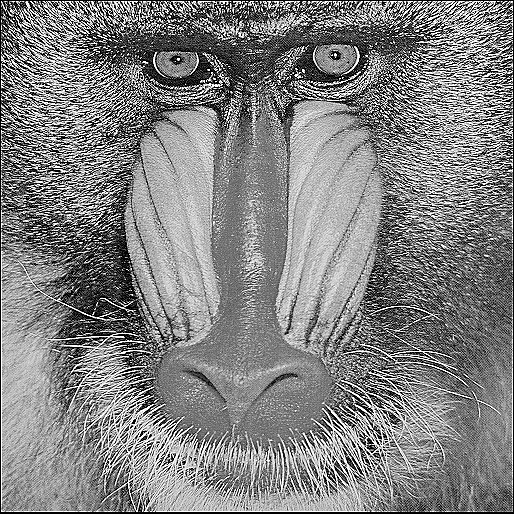

In [9]:
convolution2d(img_gray,kernel_sharpen,1,2)

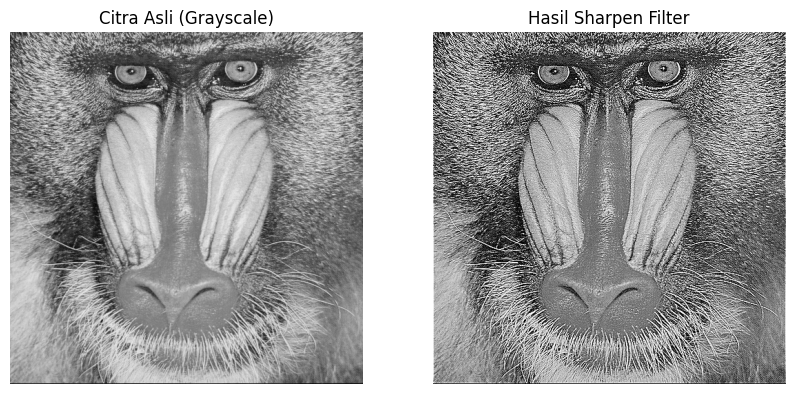

In [14]:
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32)

res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_sharpen, cmap='gray')
plt.title('Hasil Sharpen Filter')
plt.axis('off')
plt.show()

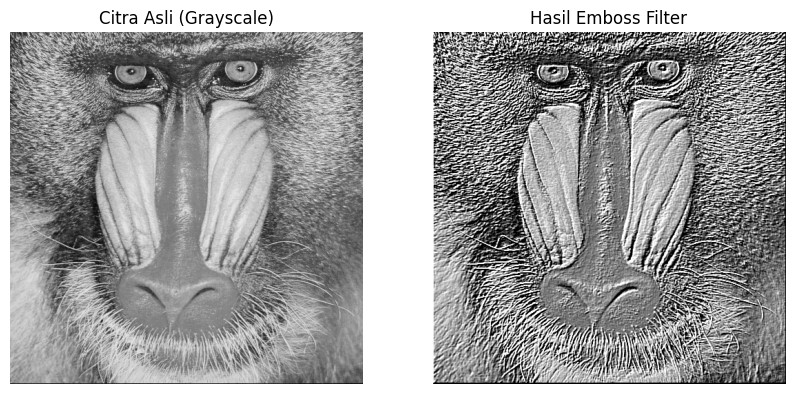

In [15]:
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]], dtype=np.float32)

res_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_emboss, cmap='gray')
plt.title('Hasil Emboss Filter')
plt.axis('off')
plt.show()

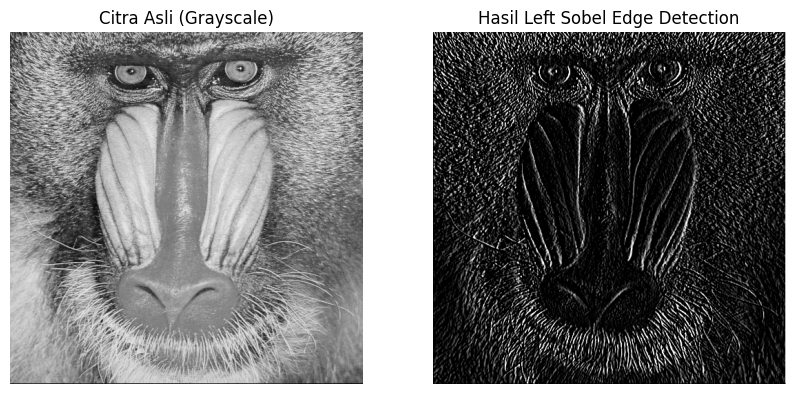

In [16]:
kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]], dtype=np.float32)

res_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_sobel, cmap='gray')
plt.title('Hasil Left Sobel Edge Detection')
plt.axis('off')
plt.show()

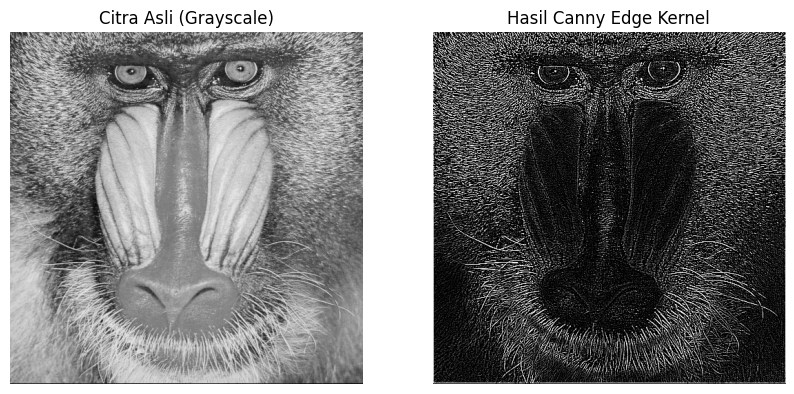

In [17]:
kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]], dtype=np.float32)

res_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_canny, cmap='gray')
plt.title('Hasil Canny Edge Kernel')
plt.axis('off')
plt.show()

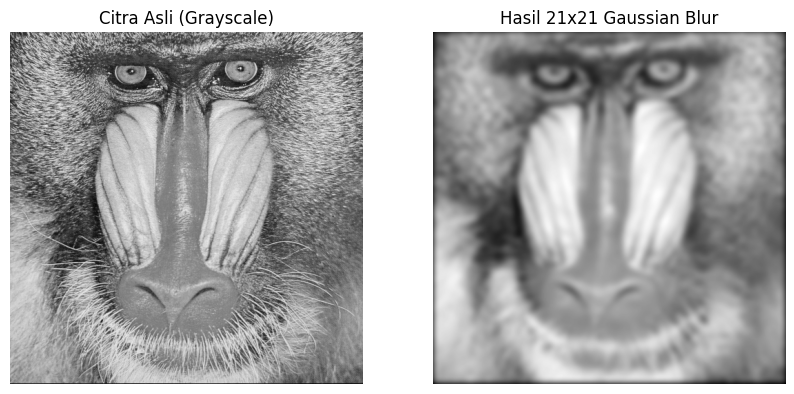

In [18]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel_21 = gaussian_1d @ gaussian_1d.transpose()

res_gauss21 = convolution2d(img_gray, gauss_kernel_21, stride=1, padding=10)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_gauss21, cmap='gray')
plt.title('Hasil 21x21 Gaussian Blur')
plt.axis('off')
plt.show()